In [25]:
import numpy as np
import matplotlib.pyplot as plt
from numba import jit 
import time

from IPython import display
import pylab as pl




In [26]:
def Jacobi_Solver_AD(x, u, v, source, dx, dy, dt, L, tol, max_iter, w):  
    betax = (dt * L)/ dx**2
    betay = (dt * L)/ dy**2

    cx = dt/(2 * dx)
    cy = dt/(2 * dy)

    b = x.copy()[1:-1, 1:-1] + dt * source

    residual = []
    iterations = 0
    error = 1
    
    while (error > tol) and (iterations < max_iter):
        R = b - ((1 + 2 * betax + 2 * betay) * x[1:-1, 1:-1] + (u[1:-1, 1:-1] * cx - betax) * x[1:-1, 2:] -  (u[1:-1, 1:-1] * cx + betax) * x[1:-1, :-2]  + (v[1:-1, 1:-1] * cy - betay) * x[2:, 1:-1] - (v[1:-1, 1:-1] * cy + betay) * x[:-2, 1:-1])
        x[1:-1, 1:-1] = x[1:-1, 1:-1] + (w/(1 + 2 * betax + 2 * betay)) * R
            
        error = np.max(np.abs(R))
        
        residual.append(error)
        
        iterations += 1

    return x, residual

def Jacobi_Solver_AD_T(x, u, v, source, dx, dy, dt, L, tol, w):  
    
    betax = (dt * L)/ dx**2
    betay = (dt * L)/ dy**2

    cx = dt/(2 * dx)
    cy = dt/(2 * dy)

    b = x.copy()[1:-1, 1:-1] + dt * source

    x[1:-1, 1:-1] = 25

    residual = []
    iterations = 0
    error = 1
    
    while error > tol:
        R = b - ((1 + 2 * betax + 2 * betay) * x[1:-1, 1:-1] + (u[1:-1, 1:-1] * cx - betax) * x[1:-1, 2:] -  (u[1:-1, 1:-1] * cx + betax) * x[1:-1, :-2]  + (v[1:-1, 1:-1] * cy - betay) * x[2:, 1:-1] - (v[1:-1, 1:-1] * cy + betay) * x[:-2, 1:-1])
        x[1:-1, 1:-1] = x[1:-1, 1:-1] + (w/(1 + 2 * betax + 2 * betay)) * R
        
        error = np.max(np.abs(R))  
        
        residual.append(error)

        iterations += 1

        EnforceTemperatureBoundary(x)
        
    return x, residual

def EnforceBoundaryConditions(u, v):
    #Left
    u[:, 0] = 0
    #Right
    u[:, -1] = 0
    #Top
    u[-1, :] = 0
    #Bottom
    u[0, :] = 0

    #Left
    v[:, 0] = 0
    #Right
    v[:, -1] = 0
    #Top
    v[-1, :] = 0
    #Bottom
    v[0, :] = 0

    return u, v

def EnforcePressureBoundary(p):
    #Top
    p[-1, :] = p[-2, :]
    #Left
    p[:, 0] = p[:, 1]
    #Right
    p[:, -1] = p[:, -2]
    #Bottom
    p[0, :] = p[1, :]

    return p

def EnforceTemperatureBoundary(T):
    #Top
    T[-1, :] = T[-2, :]
    #Left
    T[:, 0] = 30
    #Right
    T[:, -1] = 20
    #Bottom
    T[0, :] = T[1, :]

    return T

def SIMPLE_Solver(Nx, Ny, dx, dy, dt, Nu, alpha, B, To, g, numTimesteps, tol_p, tol_m, tol_t, w, count, max_iter):
    
    u = np.zeros((Ny, Nx))
    v = np.zeros((Ny, Ny))
    p = np.zeros((Ny, Ny))
    T = To * np.ones((Ny, Nx))

    u, v = EnforceBoundaryConditions(u, v)
    T = EnforceTemperatureBoundary(T)

    residuals_u = []
    residuals_v = []
    residuals_T = []

    X, Y, fig, (ax0, ax1) = Create_Solution_Plot(Nx, Ny, 1, 1)

    for n in range(numTimesteps):
        #Solve Navier stokes with current pressure grid
        sourcex = -(p[1:-1, 2:] - p[1:-1, :-2])/(2*dx)
        boyouancy = (1 - B*(T[1:-1, 1:-1]-To))*g
        
        sourcey = -(p[2:, 1:-1] - p[:-2, 1:-1])/(2*dy) + boyouancy

        u_star, residual_u = Jacobi_Solver_AD(u, u, v, sourcex, dx, dy, dt, Nu, tol_m, max_iter, w)
        v_star, residual_v = Jacobi_Solver_AD(v, u, v, sourcey, dx, dy, dt, Nu, tol_m, max_iter, w)

        residuals_u.extend(residual_u)
        residuals_v.extend(residual_v)
        
        #Solve pressure correction grid
        dp = CalculatePressureCorrection(u, v, Nx, Ny, dx, dy, dt, tol_p, max_iter)

        du = -(dt/(2*dx)) * (dp[1:-1, 2:] - dp[1:-1, :-2])
        dv = -(dt/(2*dy)) * (dp[2:, 1:-1] - dp[:-2, 1:-1])

        #Update pressure and velocity with pressure correction grid
        u[1:-1, 1:-1] = u_star[1:-1, 1:-1] + du
        v[1:-1, 1:-1] = v_star[1:-1, 1:-1] + dv
        p[1:-1, 1:-1] += dp[1:-1, 1:-1]

        u, v = EnforceBoundaryConditions(u, v)

        #Solve Temperature equation
        T, residual_T = Jacobi_Solver_AD_T(T, u, v, 0, dx, dy, dt, alpha, tol_t, w)
        T = EnforceTemperatureBoundary(T)

        residuals_T.extend(residual_T) 

        if (n % count == 0):
            print(f"Iteration {n}")
            Plot_Solution_Transient(u, v, p, T, X, Y, fig, ax0, ax1, residuals_u, residuals_v, residuals_T)

    Plot_Solution_Pressure(p, X, Y)
    return u, v, p, T

def CalculatePressureCorrection(u, v, Nx, Ny, dx, dy, dt, tol, max_iter):

    residual = (v[2:, 1:-1] - v[:-2, 1:-1])/(2*dy) + (u[1:-1, 2:] - u[1:-1, :-2])/(2*dx)

    b = -residual/dt

    betax = 1/dx**2
    betay = 1/dy**2

    alpha = 2*(betax + betay)
    
    iterations = 0
    error = 1

    dp = np.zeros((Ny, Nx))

    while error > tol and iterations < max_iter:
        R = b - (alpha*dp[1:-1, 1:-1] - betax * dp[2:, 1:-1] - betax * dp[:-2, 1:-1] - betay * dp[1:-1, 2:] - betay * dp[1:-1, :-2])
        dp[1:-1, 1:-1] = dp[1:-1, 1:-1] + (1/alpha) * R

        dp = EnforcePressureBoundary(dp)
        error = np.max(np.abs(R))
        iterations += 1

    return dp

def Create_Solution_Plot(Nx, Ny, Lx, Ly):
    X, Y = GetMeshGrid(Nx, Ny, Lx, Ly)
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(22, 11))


    ax1.set_yscale('log')
    ax1.legend(["X-momentum", "Y-Momentum", "Energy"])

    plt.xlabel("Iterations")
    plt.ylabel("Residual")

    return X, Y, fig, (ax0, ax1)

def Plot_Solution_Transient(u, v, p, T, X, Y, fig, ax0, ax1, residual_u, residual_v, residual_T): 

    display.clear_output(wait=True)
    display.display(pl.gcf())

    cp = ax0.contourf(X, Y, T, levels = 20)
    #cs = ax0.contour(X, Y, p, levels = 5, colors = 'k')

    ax0.quiver(X, Y, u, v)

    #ShapeResiduals(residual_u, residual_v, residual_T, count)
    ax1.plot(residual_u, "k")
    ax1.plot(residual_v, "r")
    #ax1.plot(residual_T, "b")

def Plot_Solution_Pressure(p, X, Y):
    plt.figure()
    cp = plt.contourf(X, Y, p)
    plt.colorbar(cp)


def Plot_Scalar_Field(phi, Nx, Ny, Lx, Ly):
    X, Y = GetMeshGrid(Nx, Ny, Lx, Ly)
    plt.figure(figsize=[11 ,11])
    cp = plt.contourf(X, Y, phi, levels = 20)
    plt.colorbar(cp)
    

def GetMeshGrid(Nx, Ny, Lx, Ly):
    x = np.linspace(0, Lx, Nx)
    y = np.linspace(0, Ly, Ny)

    X, Y = np.meshgrid(x, y)
    return X, Y

In [27]:
#  Input Data #
Lx = 1
Ly = 1
dx = 0.02
dy = 0.02
dt = 0.01

pho = 1000 #Density (kg/m^3)
k = 200 #Thermal conductivity (kg/m^3)
Cp = 4180 #Thermal capacitance (J/kg * K)
mu = 8.9e-4 #Dynamic viscosity (Pa * s)
g = -9.8 #Gravity (m/s^2)
B = 100 #Thermal expansion coefficient 

To = 25 #Reference temperature

alpha = k/(pho * Cp) # Thermal diffusivity
Nu = mu/pho # Kinematic viscosity

alpha = 0.1
Nu = 0.1

t_end = 2 #Total time

numTimesteps = int(t_end/dt)
Nx = int(Lx/dx) + 1
Ny = int(Ly/dy) + 1

CFL = dt/dx
dT = 10

Ra = (B * dT * Lx**3 * 9.8)/(Nu * alpha)
Ra = "{:e}".format(Ra)

print("Properties:")
print(f"Nx = {Nx}")
print(f"Ny = {Ny}")

print(f"CFL = {CFL}")
print(f"Ra = {Ra}")
print(f"Thermal Diffusivity = {alpha}")
print(f"Kinematic Viscosity = {Nu}")


Properties:
Nx = 51
Ny = 51
CFL = 0.5
Ra = 9.800000e+05
Thermal Diffusivity = 0.1
Kinematic Viscosity = 0.1


KeyboardInterrupt: 

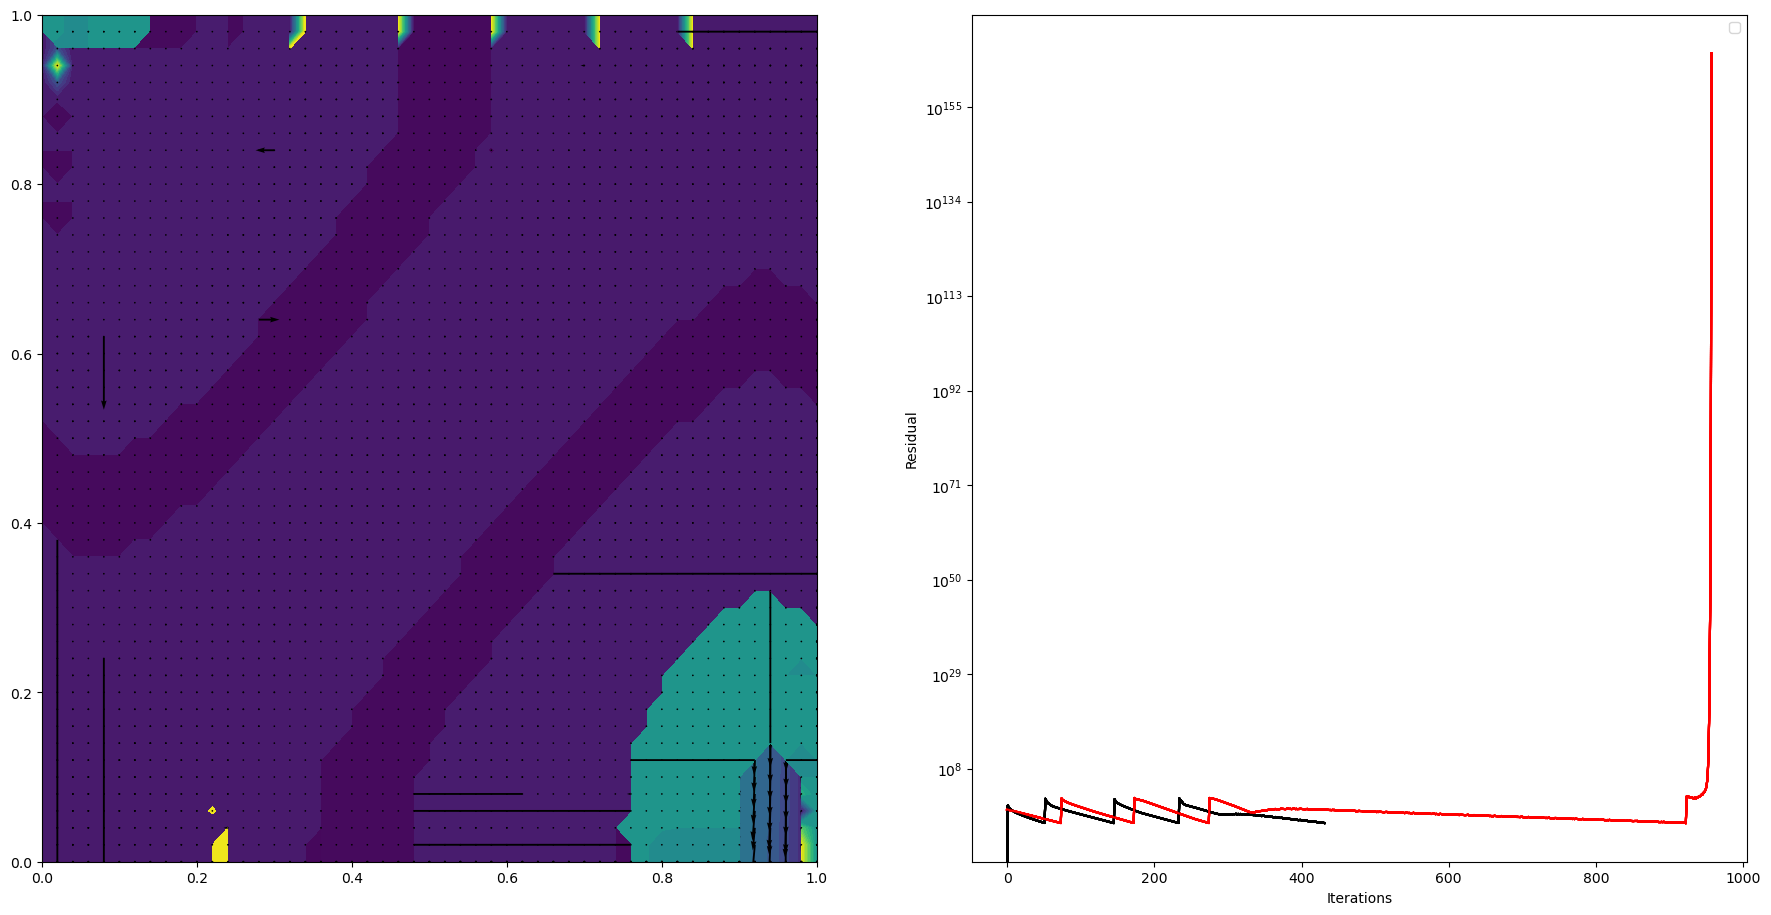

In [28]:
u, v, p, T = SIMPLE_Solver(Nx, Ny, dx, dy, dt, Nu, alpha, B, To, g, numTimesteps, tol_m = 1e-4, tol_p = 1e-4, tol_t = 1e-4, w = 1, count = 2, max_iter = 5000)
